# Fix Scalers

In [1]:
model = 'lcdm_nu'


## Init

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from emu_like.datasets import Dataset
from emu_like.scalers import Scaler

root = '/ceph/hpc/data/s25r06-05-users'
data_ranges = ['thin', 'std', 'ext']

In [3]:
def print_sign(data):
    y_min = data.min()
    y_max = data.max()
    if np.sign(y_min) == np.sign(y_max):
        if np.sign(y_min) == 1:
            sign = '+'
        else:
            sign = '-'
    else:
        sign = '+/-'
    print('sign {:3}, min {:.2e}, max {:.2e}'.format(sign, y_min, y_max))

    return

In [4]:
def scale_data(data, scaler):
    scal = Scaler.choose_one(scaler)
    scal.fit(data)
    data_scaled = scal.transform(data)
    return data_scaled

In [5]:
def plot_mode_density(
        samples,
        mode_values=None,
        n_bins=100,
        n_levels=30,
        cmap='viridis',
        zero_color='lightgray',
        logy=False):
    """
    Visualise the per-mode sample density of a 2D array with shape (n_s, n_k).

    Parameters
    ----------
    samples : np.ndarray
        Array of shape (n_s, n_k); each column holds the n_s samples of one mode.
    mode_values : array-like or None
        Optional x-axis ticks for the modes. Defaults to simple indices.
    n_bins : int
        Number of bins used to estimate the 1D density along the sample axis.
    levels : int
        Number of contour levels for plt.contourf.
    cmap : str
        Matplotlib colormap name for the filled contours.
    """
    if samples.ndim != 2:
        raise ValueError('samples must be a 2D array (n_s, n_k)')

    n_s, n_k = samples.shape
    if mode_values is None:
        mode_values = np.arange(n_k)

    y_edges = np.linspace(samples.min(), samples.max(), n_bins + 1)
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    density = np.empty((n_bins, n_k))
    for j in range(n_k):
        hist, _ = np.histogram(samples[:, j], bins=y_edges, density=True)
        density[:, j] = hist

    positive = density[density > 0]
    if positive.size == 0:
        raise ValueError('All densities are zero; adjust binning.')

    min_pos = positive.min()
    max_pos = positive.max()
    levels = np.linspace(min_pos, max_pos, n_levels)

    X, Y = np.meshgrid(mode_values, y_centers)

    fig, ax = plt.subplots(figsize=(10, 6))
    contour = ax.contourf(X, Y, density, levels=levels, cmap=cmap, extend='min')
    contour.cmap.set_under(zero_color)     # color for density == 0
    contour.changed()

    ax.set_xlabel('Mode index' if mode_values is None else 'Mode')
    ax.set_ylabel('Sample value')
    if logy:
        ax.set_yscale('log')
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Density')
    plt.show()


## pk_m (LogStandardScaler)

In [6]:
spectrum = 'pk_m'
spectrum_type = 'pk'

In [7]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [8]:
# Signs
print_sign(data.y)

sign +  , min 3.22e-04, max 1.70e+01


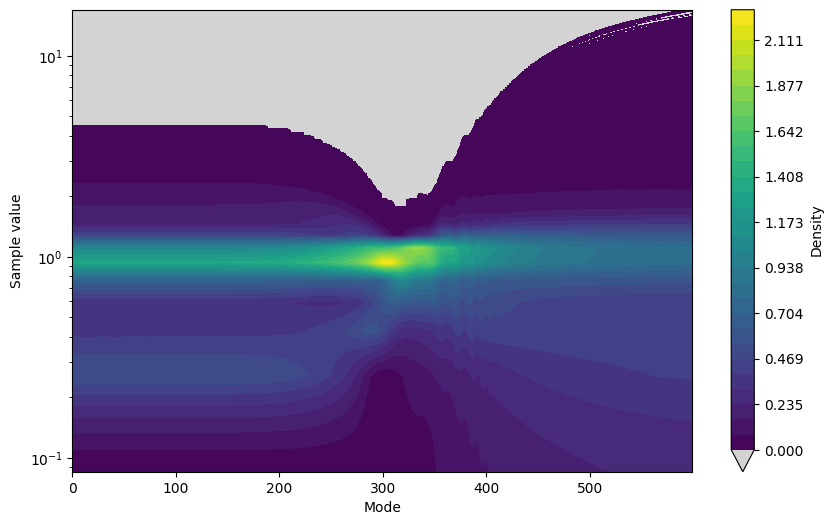

In [9]:
# Raw
plot_mode_density(data.y, logy=True)

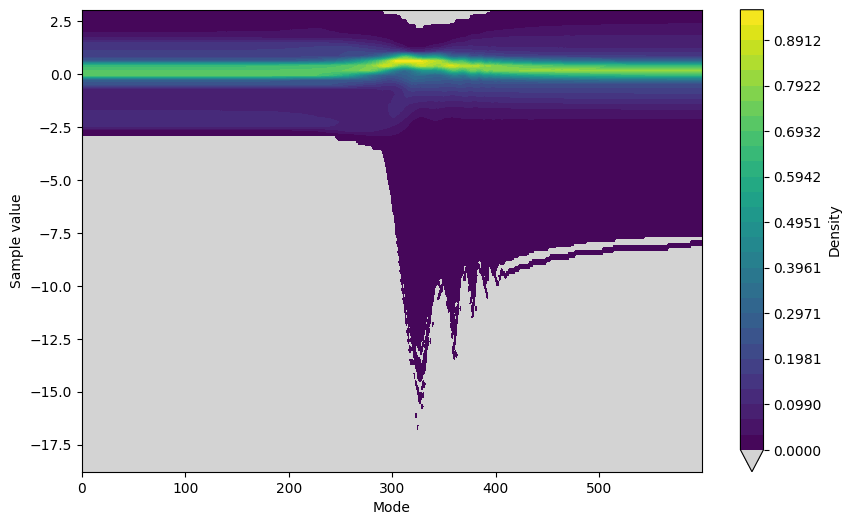

In [10]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## pk_cb (LogStandardScaler)

In [11]:
spectrum = 'pk_cb'
spectrum_type = 'pk'

In [12]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [13]:
# Signs
print_sign(data.y)

sign +  , min 5.83e-04, max 1.73e+01


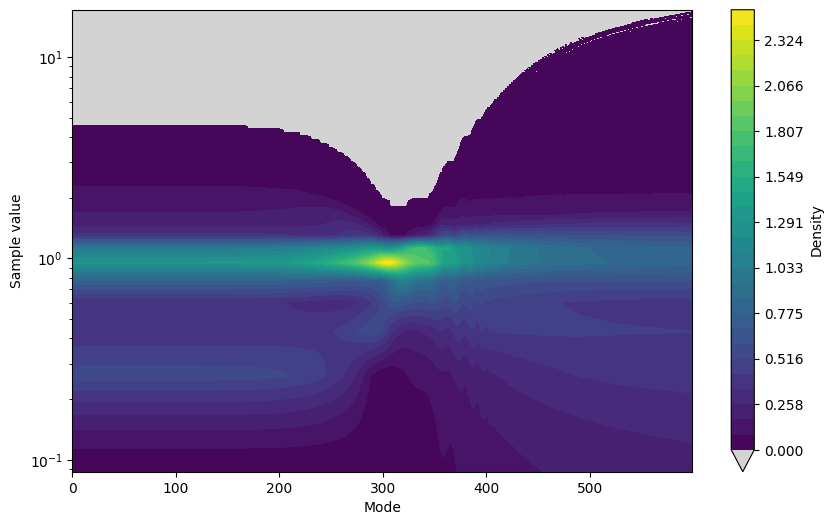

In [14]:
# Raw
plot_mode_density(data.y, logy=True)

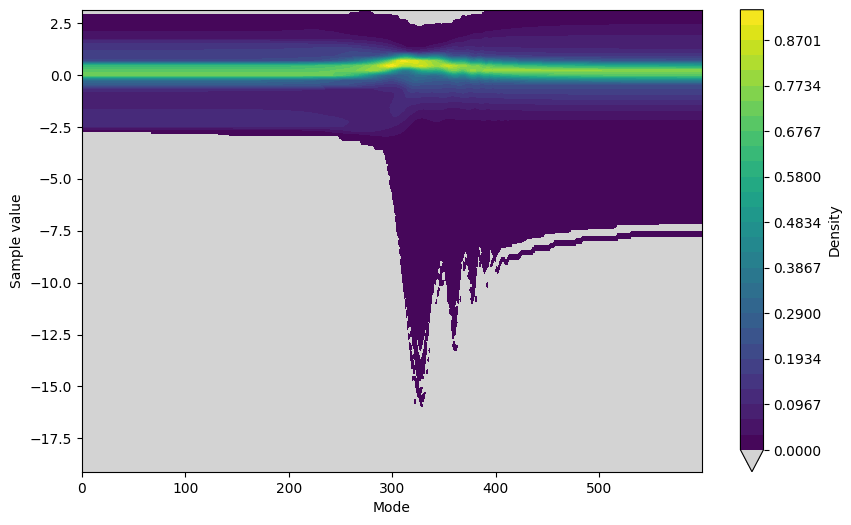

In [15]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## pk_weyl (LogStandardScaler)

In [16]:
spectrum = 'pk_weyl'
spectrum_type = 'pk'

In [17]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [18]:
# Signs
print_sign(data.y)

sign +  , min 2.28e-05, max 2.46e+02


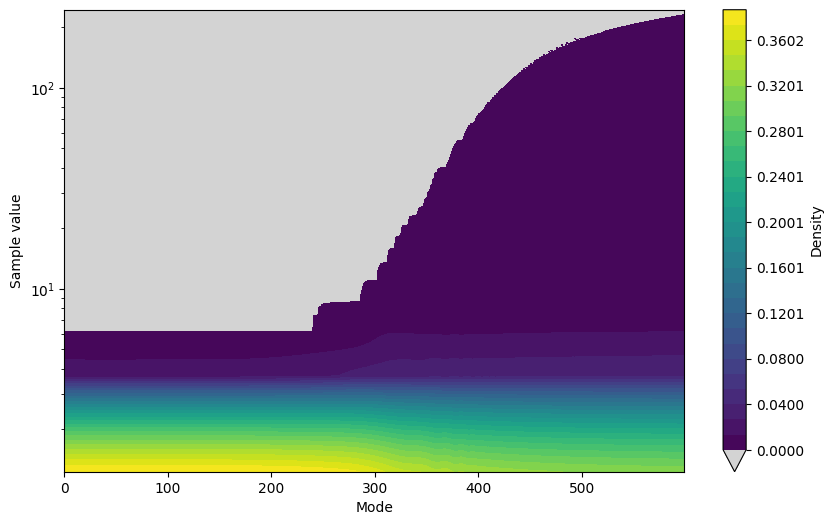

In [19]:
# Raw
plot_mode_density(data.y, logy=True)

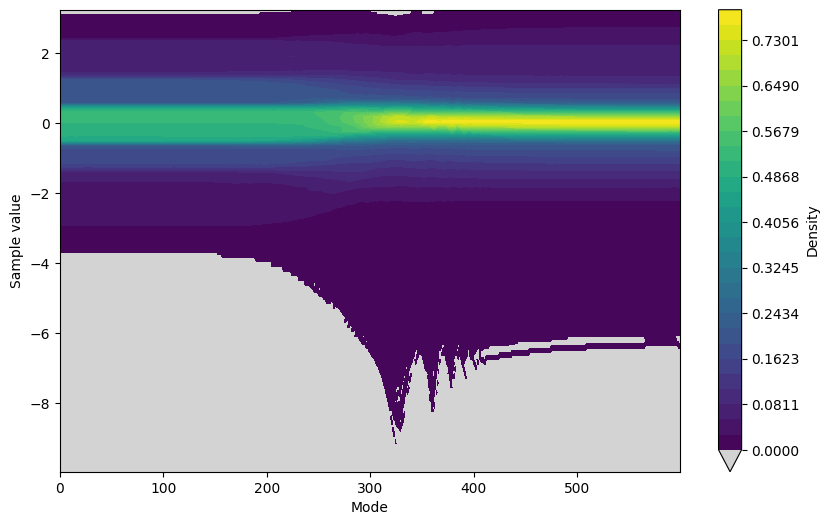

In [20]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## fk_m (StandardScaler)

In [21]:
spectrum = 'fk_m'
spectrum_type = 'pk'

In [22]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [23]:
# Signs
print_sign(data.y)

sign +  , min 3.15e-01, max 1.01e+00


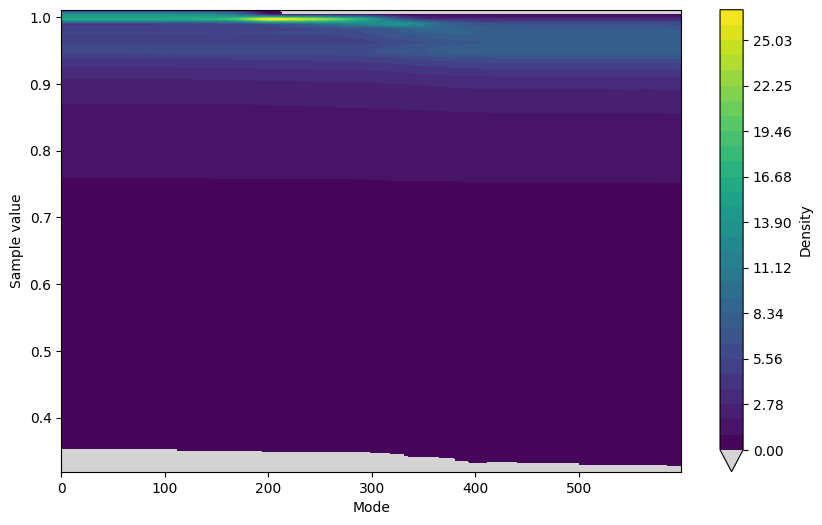

In [24]:
# Raw
plot_mode_density(data.y)

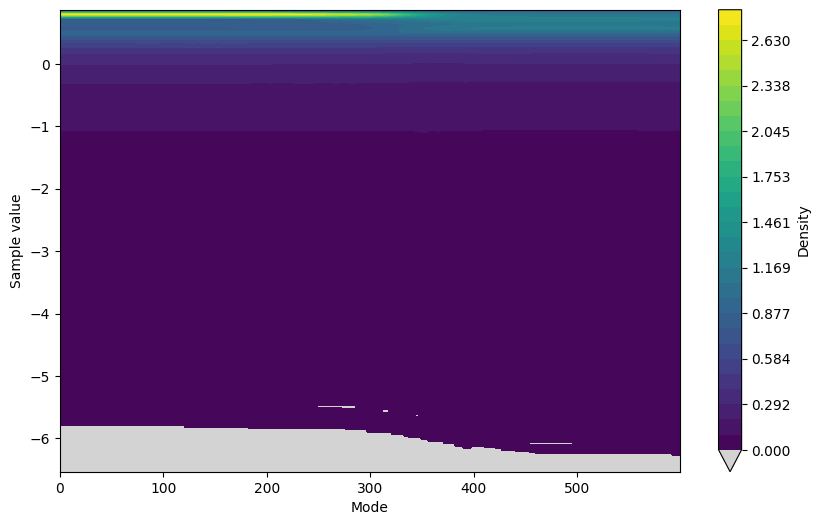

In [25]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

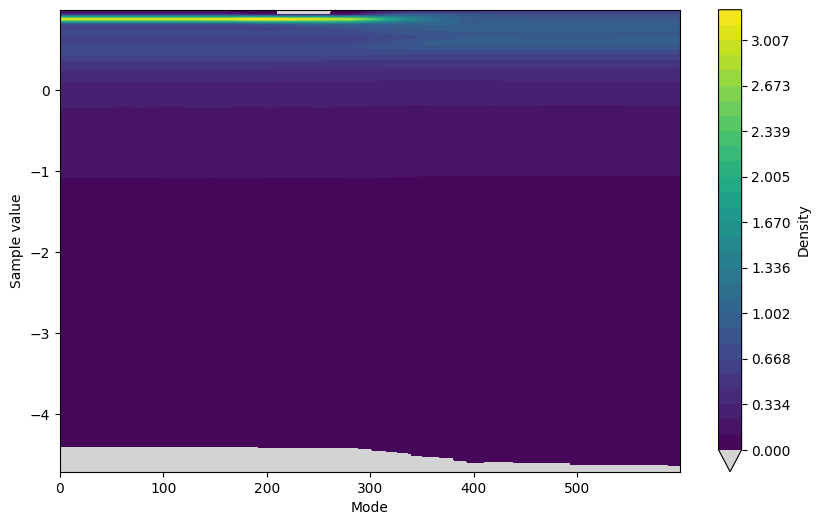

In [26]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

## fk_cb (StandardScaler)

In [27]:
spectrum = 'fk_cb'
spectrum_type = 'pk'

In [28]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [29]:
# Signs
print_sign(data.y)

sign +  , min 3.15e-01, max 1.02e+00


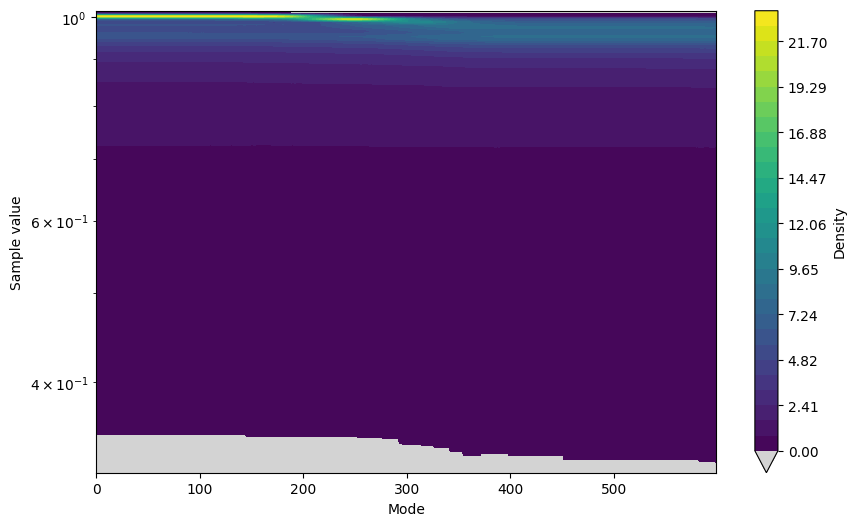

In [30]:
# Raw
plot_mode_density(data.y, logy=True)

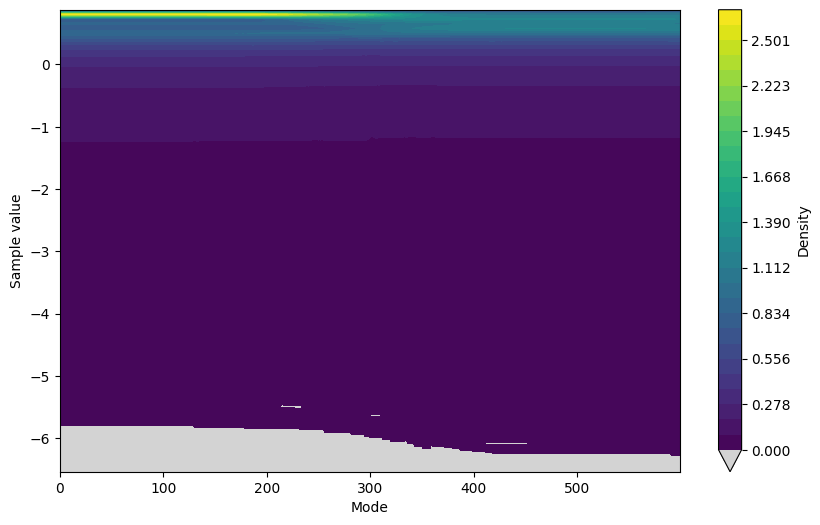

In [31]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

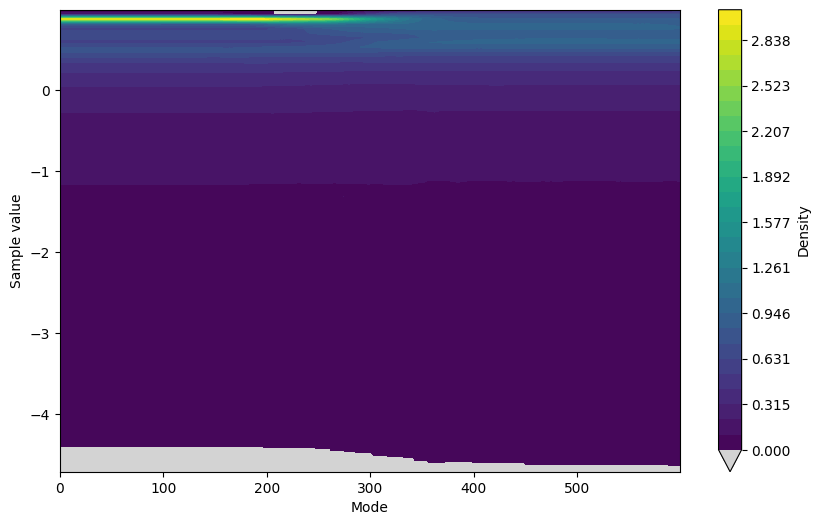

In [32]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

## fk_weyl (minus LogStandardScaler)

In [33]:
spectrum = 'fk_weyl'
spectrum_type = 'pk'

In [34]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [35]:
# Signs
print_sign(data.y)

sign -  , min -6.85e-01, max -4.07e-04


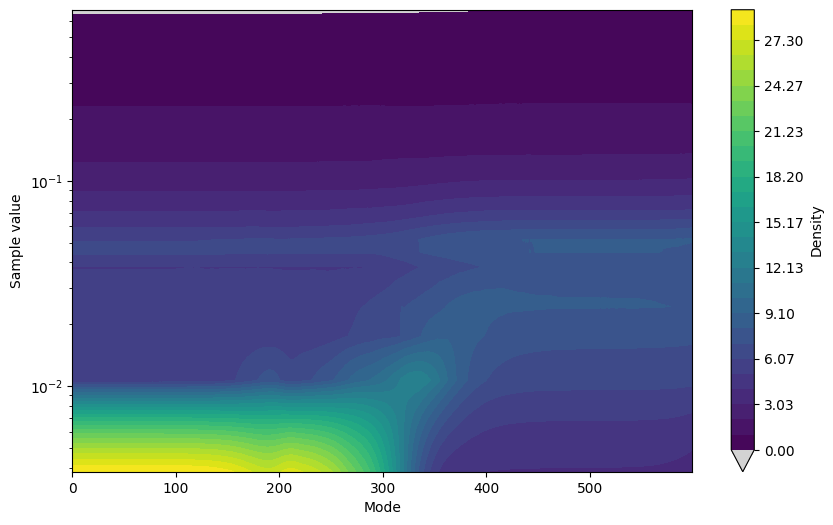

In [36]:
# Raw
plot_mode_density(-data.y, logy=True)

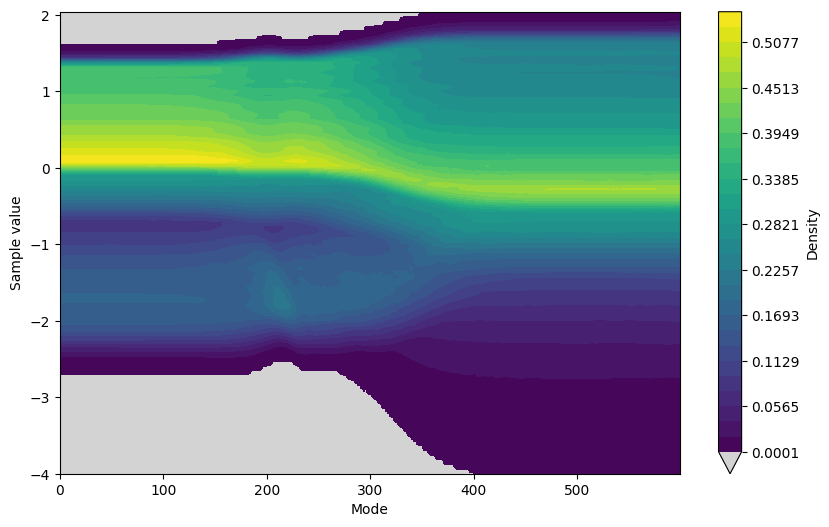

In [37]:
# LogStandardScaler
plot_mode_density(scale_data(-data.y, 'LogStandardScaler'))

## cl_TT_lensed (LogStandardScaler)

In [38]:
spectrum = 'cl_TT_lensed'
spectrum_type = 'cl'

In [39]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [40]:
# Signs
print_sign(data.y)

sign +  , min 3.18e-02, max 1.38e+01


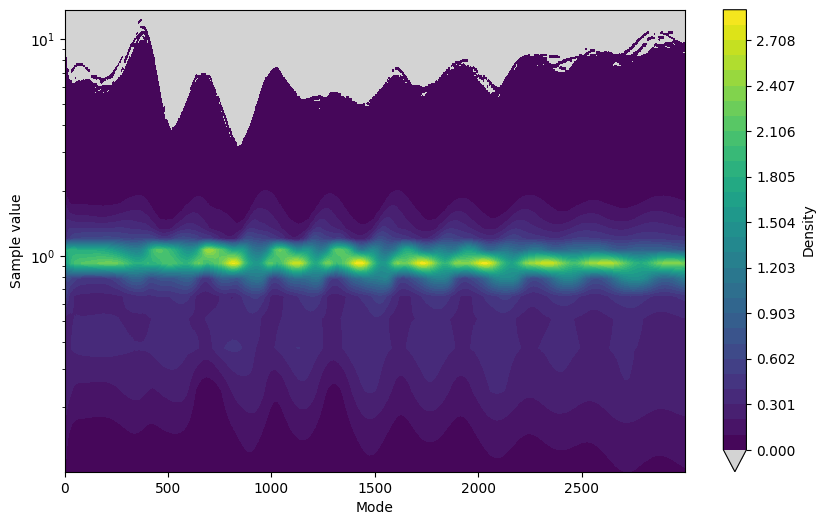

In [41]:
# Raw
plot_mode_density(data.y, logy=True)

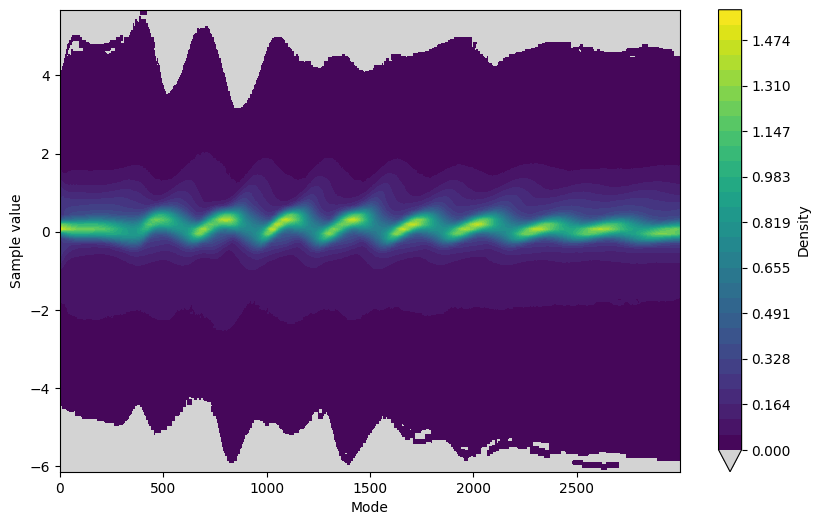

In [42]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## cl_TE_lensed (StandardScaler)

In [43]:
spectrum = 'cl_TE_lensed'
spectrum_type = 'cl'

In [44]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [45]:
# Signs
print_sign(data.y)

sign +/-, min -8.45e-11, max 1.19e-10


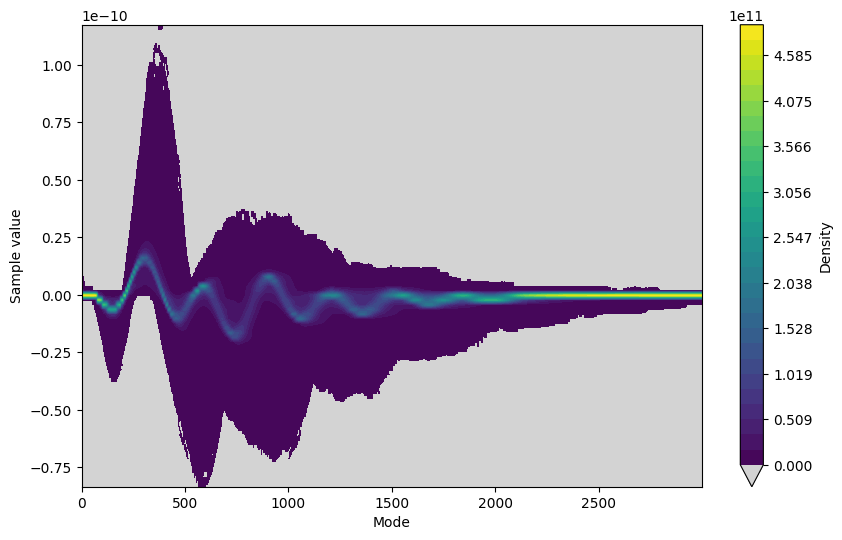

In [46]:
# Raw
plot_mode_density(data.y)

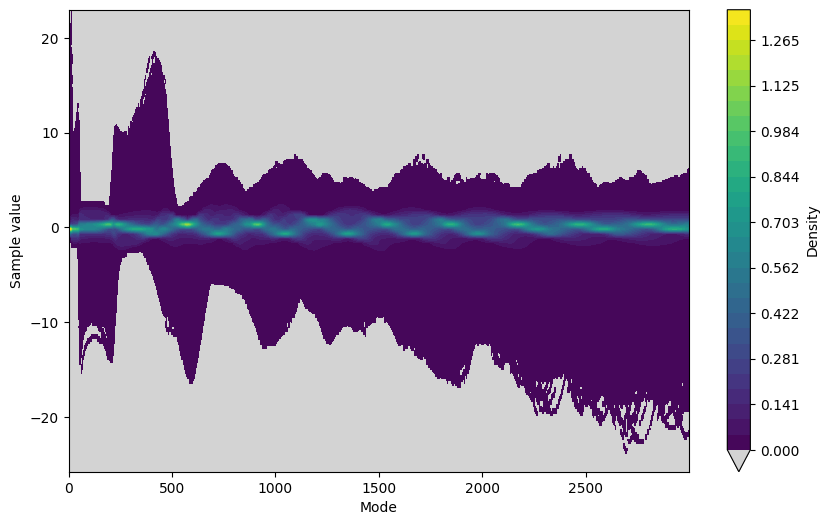

In [47]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

## cl_EE_lensed (LogStandardScaler)

In [48]:
spectrum = 'cl_EE_lensed'
spectrum_type = 'cl'

In [49]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [50]:
# Signs
print_sign(data.y)

sign +  , min 8.22e-04, max 8.86e+02


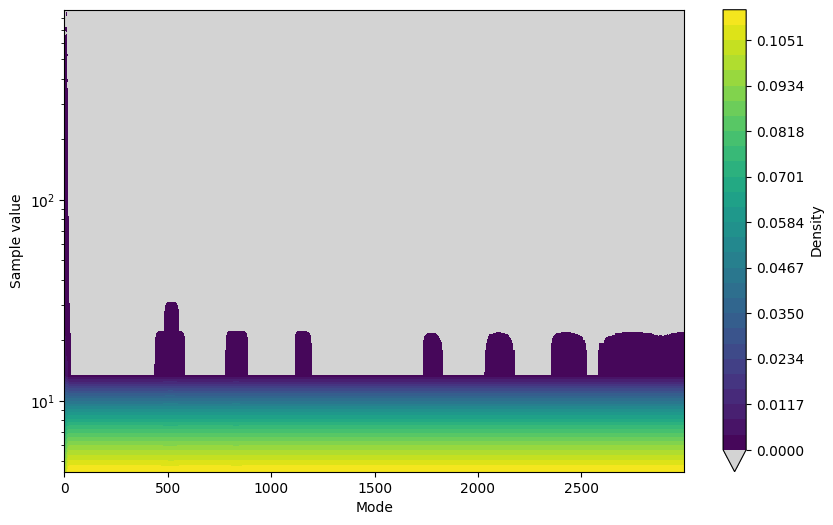

In [51]:
# Raw
plot_mode_density(data.y, logy=True)

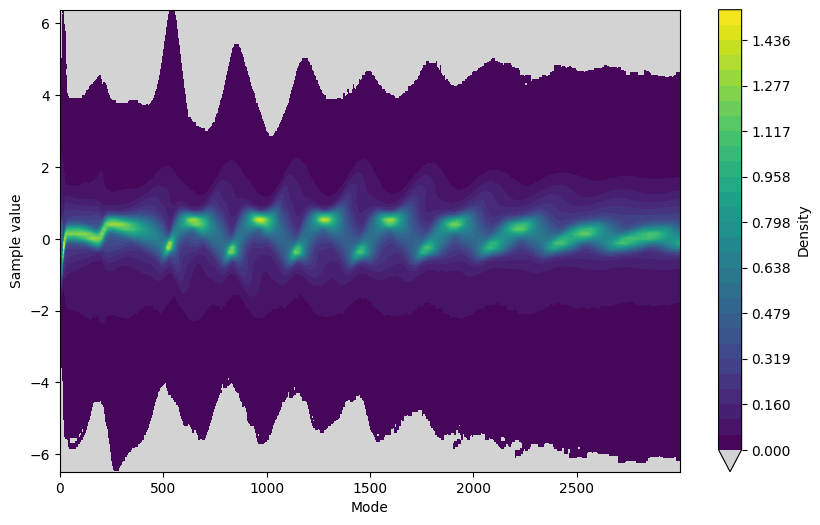

In [52]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## cl_BB_lensed (LogStandardScaler)

In [53]:
spectrum = 'cl_BB_lensed'
spectrum_type = 'cl'

In [54]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [55]:
# Signs
print_sign(data.y)

sign +  , min 1.67e-03, max 7.59e+01


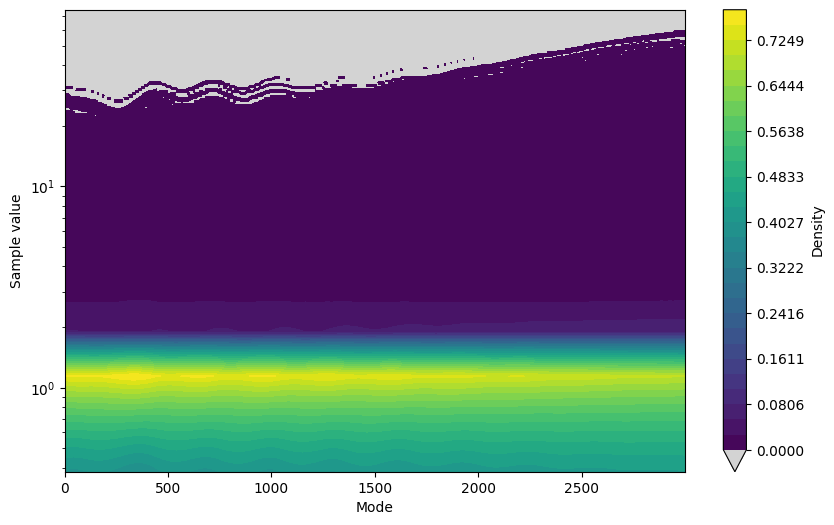

In [56]:
# Raw
plot_mode_density(data.y, logy=True)

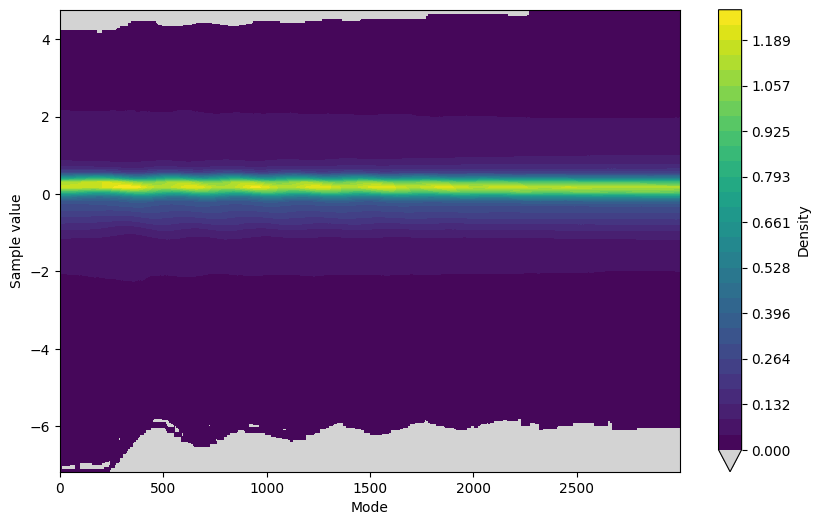

In [57]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## cl_Tp_lensed (StandardScaler)

In [58]:
spectrum = 'cl_Tp_lensed'
spectrum_type = 'cl'

In [59]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [60]:
# Signs
print_sign(data.y)

sign +/-, min -1.00e-10, max 4.36e-09


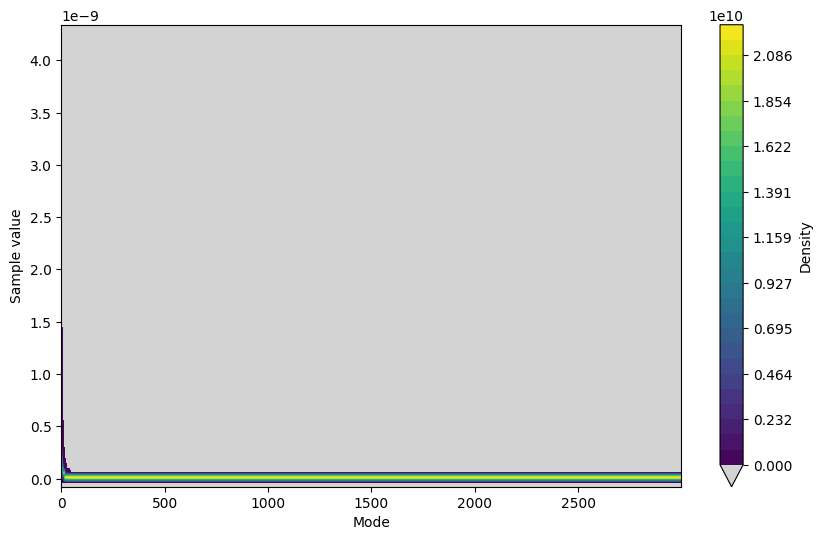

In [61]:
# Raw
plot_mode_density(data.y)

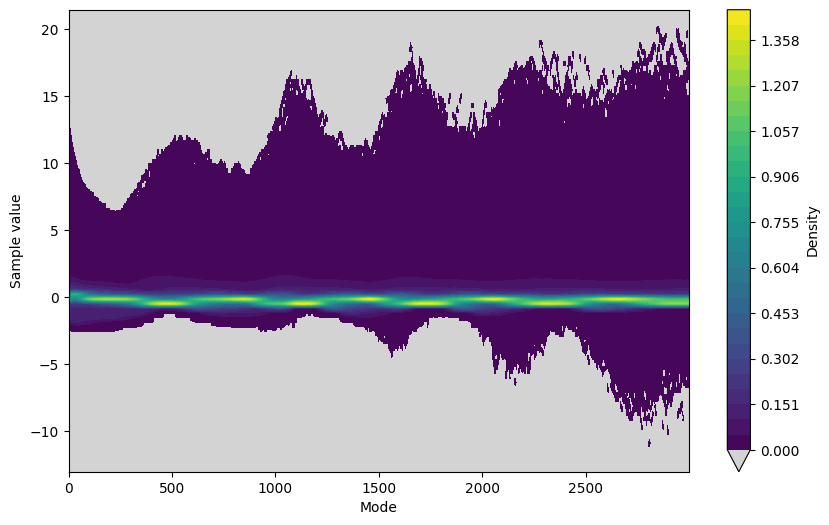

In [62]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

## cl_pp_lensed (LogStandardScaler)

In [63]:
spectrum = 'cl_pp_lensed'
spectrum_type = 'cl'

In [64]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [65]:
# Signs
print_sign(data.y)

sign +  , min 9.90e-04, max 6.69e+01


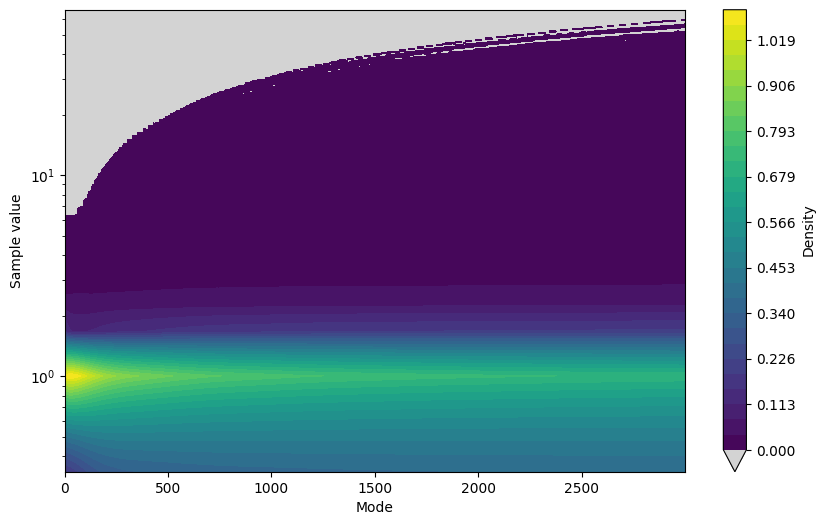

In [66]:
# Raw
plot_mode_density(data.y, logy=True)

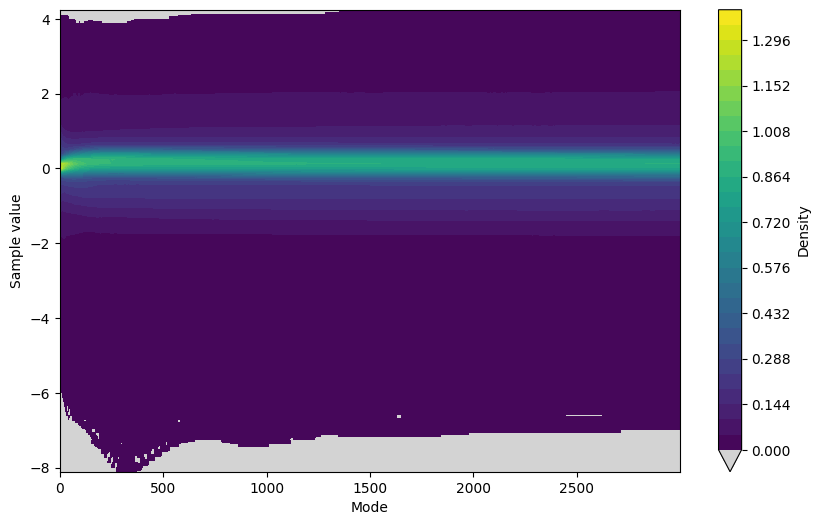

In [67]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))